# 01 - Tiền xử lý dữ liệu dự báo năng lượng

Notebook này ghi lại **đúng thứ tự** dữ liệu được xử lý, từ dữ liệu thô tới ba tập train/validation/test. Nó phục vụ đề tài dự báo tiêu thụ năng lượng theo định hướng Industrial AI.

**Phạm vi và quyết định đã chốt**

- Nguồn: `data/raw/energydata_complete.csv` (UCI Appliances Energy Prediction).
- Mục tiêu: dự báo `Appliances` **sau 1 giờ**. Vì dữ liệu có tần suất 10 phút, horizon `H = 6` bước.
- Chia dữ liệu theo thời gian: 70% train, 10% validation, 20% test; tuyệt đối không shuffle.
- Không xóa các đỉnh `Appliances`: chúng là tín hiệu vận hành quan trọng cho peak shaving.
- Không scale ở đây; bước đó phải fit trên train trong notebook mô hình để tránh data leakage.

Các tài liệu PDF được dùng làm bối cảnh Industrial AI (ra quyết định, độ tin cậy và hiệu quả vận hành). Các yêu cầu thao tác dữ liệu cụ thể đến từ yêu cầu đồ án/nhóm: kiểm tra chu kỳ, missing/noise và chia chuỗi thời gian.

## Trình tự xử lý

1. Nạp dữ liệu thô và cố định cấu hình dự báo.  
2. Kiểm tra schema, missing values, trùng lặp, tính liên tục 10 phút và thứ tự thời gian.  
3. EDA ngắn: quan sát chuỗi và chu kỳ theo giờ/ngày trong tuần.  
4. Làm sạch có chủ đích: bỏ hai biến ngẫu nhiên `rv1`, `rv2`; giữ nguyên các đỉnh năng lượng hợp lệ.  
5. Tạo nhãn tương lai `t + 60 phút` và đặc trưng lịch chỉ biết được tại lúc dự báo.  
6. Loại sáu dòng cuối chưa có nhãn tương lai.  
7. Chia tuần tự train/validation/test, xác minh không giao nhau và ghi các dataset đầu ra.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'energydata_complete.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

FREQUENCY = pd.Timedelta(minutes=10)
HORIZON_STEPS = 6
HORIZON_MINUTES = int(HORIZON_STEPS * FREQUENCY.total_seconds() / 60)
TRAIN_RATIO, VALIDATION_RATIO = 0.70, 0.10

assert RAW_PATH.exists(), f'Không tìm thấy dữ liệu thô: {RAW_PATH}'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Horizon: {HORIZON_MINUTES} phút ({HORIZON_STEPS} bước)')
print(f'Dữ liệu thô: {RAW_PATH}')

Horizon: 60 phút (6 bước)
Dữ liệu thô: D:\Nam_3\HK1\UDAITCN\LT\industrial-energy-forecasting\data\raw\energydata_complete.csv


## Bước 1 - Nạp dữ liệu thô

Không đổi tên hoặc ghi đè tệp raw. Cột `date` được parse thành kiểu thời gian ngay khi đọc.

In [2]:
raw = pd.read_csv(RAW_PATH, parse_dates=['date'])
print(f'Kích thước raw: {raw.shape[0]:,} dòng x {raw.shape[1]} cột')
display(raw.head(3))
display(raw.dtypes.to_frame('dtype').T)

Kích thước raw: 19,735 dòng x 29 cột


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
dtype,datetime64[us],int64,int64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


## Bước 2 - Kiểm tra chất lượng dữ liệu

Chuỗi chỉ đủ điều kiện cho time-series forecasting khi timestamp tăng dần, không trùng và mọi khoảng cách bằng 10 phút. Các `assert` bên dưới dừng pipeline nếu một điều kiện bị vi phạm.

In [3]:
time_diff = raw['date'].diff().dropna()
quality = pd.DataFrame({
    'check': ['missing_cells', 'duplicate_rows', 'duplicate_timestamps', 'timestamps_monotonic', 'unexpected_intervals', 'negative_Appliances'],
    'value': [
        int(raw.isna().sum().sum()),
        int(raw.duplicated().sum()),
        int(raw['date'].duplicated().sum()),
        bool(raw['date'].is_monotonic_increasing),
        int((time_diff != FREQUENCY).sum()),
        int((raw['Appliances'] < 0).sum()),
    ],
})
display(quality)
print(f"Khoảng thời gian: {raw['date'].min()} đến {raw['date'].max()}")
print(f"Appliances: {raw['Appliances'].min()} đến {raw['Appliances'].max()} Wh")
print(f"rv1 và rv2 trùng hoàn toàn: {(raw['rv1'] == raw['rv2']).all()}")

assert quality.loc[quality['check'] == 'missing_cells', 'value'].item() == 0
assert quality.loc[quality['check'] == 'duplicate_rows', 'value'].item() == 0
assert quality.loc[quality['check'] == 'duplicate_timestamps', 'value'].item() == 0
assert raw['date'].is_monotonic_increasing
assert (time_diff == FREQUENCY).all()
assert (raw['Appliances'] >= 0).all()

,check,value
0,missing_cells,0
1,duplicate_rows,0
2,duplicate_timestamps,0
3,timestamps_monotonic,True
4,unexpected_intervals,0
5,negative_Appliances,0


Khoảng thời gian: 2016-01-11 17:00:00 đến 2016-05-27 18:00:00
Appliances: 10 đến 1080 Wh
rv1 và rv2 trùng hoàn toàn: True


## Bước 3 - EDA về chu kỳ ngày và tuần

Ba biểu đồ dưới đây là bằng chứng trực quan để nhóm kiểm tra tính chu kỳ kép: một lát cắt chuỗi thời gian, hồ sơ theo giờ và hồ sơ theo ngày trong tuần. Chúng được lưu vào `reports/figures/` để dùng trong báo cáo.

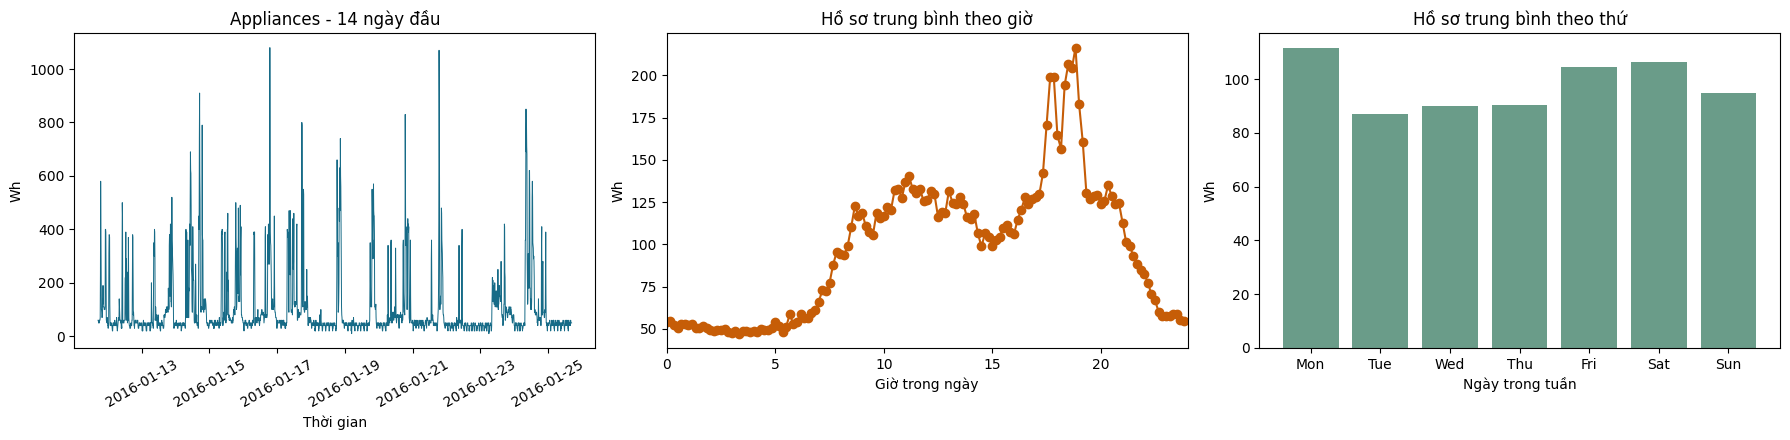

hour,0.000000,0.166667,0.333333,0.500000,0.666667,0.833333,1.000000,1.166667,1.333333,1.500000,...,22.333333,22.500000,22.666667,22.833333,23.000000,23.166667,23.333333,23.500000,23.666667,23.833333
mean_Appliances_by_hour,53.868613,54.379562,52.116788,50.656934,52.846715,52.846715,52.335766,52.627737,50.510949,50.510949,...,70.437956,66.788321,59.927007,57.810219,57.445255,57.372263,58.613139,58.978102,55.109489,54.379562


,weekday,Appliances
0,Mon,111.450684
1,Tue,87.125000
2,Wed,89.930556
3,Thu,90.434028
4,Fri,104.622144
5,Sat,106.246345
6,Sun,94.915936


In [4]:
eda = raw.assign(
    hour=raw['date'].dt.hour + raw['date'].dt.minute / 60,
    weekday=raw['date'].dt.dayofweek,
)
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
first_14_days = raw[raw['date'] < raw['date'].min() + pd.Timedelta(days=14)]
axes[0].plot(first_14_days['date'], first_14_days['Appliances'], linewidth=0.7, color='#176B87')
axes[0].set(title='Appliances - 14 ngày đầu', xlabel='Thời gian', ylabel='Wh')
axes[0].tick_params(axis='x', rotation=30)

hourly = eda.groupby('hour', as_index=False)['Appliances'].mean()
weekly = eda.groupby('weekday', as_index=False)['Appliances'].mean()
axes[1].plot(hourly['hour'], hourly['Appliances'], marker='o', color='#C65D07')
axes[1].set(title='Hồ sơ trung bình theo giờ', xlabel='Giờ trong ngày', ylabel='Wh', xlim=(0, 24))
axes[2].bar(weekday_labels, weekly['Appliances'], color='#6A9C89')
axes[2].set(title='Hồ sơ trung bình theo thứ', xlabel='Ngày trong tuần', ylabel='Wh')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_daily_weekly_cycles.png', dpi=160, bbox_inches='tight')
plt.show()

display(pd.DataFrame({
    'mean_Appliances_by_hour': hourly.set_index('hour')['Appliances'],
}).T)
display(weekly.assign(weekday=weekly['weekday'].map(dict(enumerate(weekday_labels)))))

## Bước 4 - Làm sạch và tạo đặc trưng không rò rỉ

- `rv1` và `rv2` bị bỏ vì hai cột giống hệt nhau và là biến ngẫu nhiên, nên không tạo tín hiệu dự báo hay giá trị vận hành.
- Giá trị lớn của `Appliances` vẫn được giữ nguyên. Không có giá trị âm; đỉnh tải là hiện tượng cần mô hình nhận biết, không tự động xem là lỗi.
- `Appliances_lag_0` là điện năng tại thời điểm quan sát, hợp lệ để dự báo tương lai.
- Bốn đặc trưng sin/cos được tính từ `forecast_timestamp`. Thời điểm lịch trong tương lai là thông tin biết trước, không lấy số đo cảm biến tương lai.

In [5]:
model_data = (
    raw.drop(columns=['rv1', 'rv2'])
       .rename(columns={'date': 'observation_time', 'Appliances': 'Appliances_lag_0'})
       .copy()
)
model_data['forecast_timestamp'] = model_data['observation_time'] + HORIZON_STEPS * FREQUENCY
model_data['target_Appliances_t_plus_60m'] = model_data['Appliances_lag_0'].shift(-HORIZON_STEPS)

forecast_hour = model_data['forecast_timestamp'].dt.hour + model_data['forecast_timestamp'].dt.minute / 60
forecast_weekday = model_data['forecast_timestamp'].dt.dayofweek
model_data['forecast_hour_sin'] = np.sin(2 * np.pi * forecast_hour / 24)
model_data['forecast_hour_cos'] = np.cos(2 * np.pi * forecast_hour / 24)
model_data['forecast_weekday_sin'] = np.sin(2 * np.pi * forecast_weekday / 7)
model_data['forecast_weekday_cos'] = np.cos(2 * np.pi * forecast_weekday / 7)

rows_without_future_target = int(model_data['target_Appliances_t_plus_60m'].isna().sum())
model_data = model_data.dropna(subset=['target_Appliances_t_plus_60m']).reset_index(drop=True)
assert rows_without_future_target == HORIZON_STEPS
assert model_data.isna().sum().sum() == 0
print(f'Đã loại {rows_without_future_target} dòng cuối vì chưa có nhãn t+60 phút.')
print(f'Kích thước sau tạo nhãn: {model_data.shape[0]:,} dòng x {model_data.shape[1]} cột')
display(model_data[['observation_time', 'forecast_timestamp', 'Appliances_lag_0', 'target_Appliances_t_plus_60m']].head(3))

Đã loại 6 dòng cuối vì chưa có nhãn t+60 phút.
Kích thước sau tạo nhãn: 19,729 dòng x 33 cột


,observation_time,forecast_timestamp,Appliances_lag_0,target_Appliances_t_plus_60m
0,2016-01-11 17:00:00,2016-01-11 18:00:00,60,60.0
1,2016-01-11 17:10:00,2016-01-11 18:10:00,60,60.0
2,2016-01-11 17:20:00,2016-01-11 18:20:00,50,60.0


## Bước 5 - Chia train/validation/test theo thời gian

Không dùng `train_test_split` vì mặc định có thể shuffle. Validation dùng để chọn mô hình/hyperparameter; test chỉ dùng một lần để đánh giá cuối cùng.

In [6]:
n_rows = len(model_data)
train_end = int(n_rows * TRAIN_RATIO)
validation_end = int(n_rows * (TRAIN_RATIO + VALIDATION_RATIO))

model_data['split'] = 'test'
model_data.loc[:train_end - 1, 'split'] = 'train'
model_data.loc[train_end:validation_end - 1, 'split'] = 'validation'

train = model_data[model_data['split'] == 'train'].copy()
validation = model_data[model_data['split'] == 'validation'].copy()
test = model_data[model_data['split'] == 'test'].copy()

assert train['observation_time'].max() < validation['observation_time'].min() < test['observation_time'].min()
assert len(train) + len(validation) + len(test) == n_rows
split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train), len(validation), len(test)],
    'start_observation': [train['observation_time'].min(), validation['observation_time'].min(), test['observation_time'].min()],
    'end_observation': [train['observation_time'].max(), validation['observation_time'].max(), test['observation_time'].max()],
})
split_summary['ratio'] = split_summary['rows'] / n_rows
display(split_summary)

,split,rows,start_observation,end_observation,ratio
0,train,13810,2016-01-11 17:00:00,2016-04-16 14:30:00,0.699985
1,validation,1973,2016-04-16 14:40:00,2016-04-30 07:20:00,0.100005
2,test,3946,2016-04-30 07:30:00,2016-05-27 17:00:00,0.200010


## Bước 6 - Ghi đầu ra có thể tái lập

Các file dưới đây là đầu vào chuẩn cho notebook huấn luyện mô hình. Tệp đầy đủ có cột `split` để truy vết; ba tệp riêng giúp thao tác mô hình rõ ràng.

In [7]:
output_files = {
    'full': PROCESSED_DIR / 'energy_forecasting_h1_full.csv',
    'train': PROCESSED_DIR / 'energy_forecasting_h1_train.csv',
    'validation': PROCESSED_DIR / 'energy_forecasting_h1_validation.csv',
    'test': PROCESSED_DIR / 'energy_forecasting_h1_test.csv',
}
model_data.to_csv(output_files['full'], index=False)
train.to_csv(output_files['train'], index=False)
validation.to_csv(output_files['validation'], index=False)
test.to_csv(output_files['test'], index=False)

quality_summary = {
    'source_file': str(RAW_PATH.relative_to(PROJECT_ROOT)),
    'raw_rows': int(len(raw)),
    'raw_columns': int(raw.shape[1]),
    'frequency_minutes': int(FREQUENCY.total_seconds() / 60),
    'horizon_steps': HORIZON_STEPS,
    'horizon_minutes': HORIZON_MINUTES,
    'missing_cells_raw': int(raw.isna().sum().sum()),
    'duplicate_rows_raw': int(raw.duplicated().sum()),
    'duplicate_timestamps_raw': int(raw['date'].duplicated().sum()),
    'unexpected_intervals_raw': int((time_diff != FREQUENCY).sum()),
    'dropped_columns': ['rv1', 'rv2'],
    'dropped_rows_without_future_label': rows_without_future_target,
    'target_column': 'target_Appliances_t_plus_60m',
    'split_rows': {name: int(len(frame)) for name, frame in [('train', train), ('validation', validation), ('test', test)]},
    'split_boundaries': split_summary.astype({'start_observation': str, 'end_observation': str}).to_dict(orient='records'),
}
with (PROCESSED_DIR / 'data_quality_summary.json').open('w', encoding='utf-8') as file:
    json.dump(quality_summary, file, ensure_ascii=False, indent=2)

for name, path in output_files.items():
    print(f'{name:10s} -> {path.relative_to(PROJECT_ROOT)} ({path.stat().st_size / 1024:.1f} KiB)')
print('data_quality_summary.json đã được ghi.')

full       -> data\processed\energy_forecasting_h1_full.csv (6915.7 KiB)
train      -> data\processed\energy_forecasting_h1_train.csv (4847.9 KiB)
validation -> data\processed\energy_forecasting_h1_validation.csv (689.5 KiB)
test       -> data\processed\energy_forecasting_h1_test.csv (1378.8 KiB)
data_quality_summary.json đã được ghi.


## Bước kế tiếp (không thực hiện trong notebook này)

Huấn luyện baseline/model chỉ với các tệp đã chia. Nếu cần scale, fit scaler trên `train` rồi transform `validation` và `test`. Khi báo cáo kết quả, liên hệ sai số dự báo với quyết định peak shaving và con người là người phê duyệt hành động.